## 1. Clean your Datasets

For the first part of your project, you will apply the same data cleaning steps to your "data/control.txt" and "data/treatment.txt" files. By the end of this step, you should have two lists of floats that match the numbers you have in each respective file.

You will implement your `clean_data` function in your `cleaner.py` module and import the module in the code-block below.

In [1]:
# TODO: import all the packages that you will need for this notebook here
import statistics as stats
import matplotlib.pyplot as plt

import cleaner

In [5]:
# TODO: read your text files into your code using file I/O
with open('data/control.txt') as f:
    control_raw = f.readlines()

with open('data/treatment.txt') as f:
    treatment_raw = f.readlines()

# TODO: clean both list objects that you created above using the 'clean_data' function
control = cleaner.clean_data(control_raw)
treatment = cleaner.clean_data(treatment_raw)

## 2. Explore your Datasets

Now that you have your list objects created and cleaned, let's explore the descriptive statistics of these two files and make subsequent observations on our data.

In [6]:
# TODO: Calculate the standard deviation of both the control and treatment group
control_stdev = stats.stdev(control)
treatment_stdev = stats.stdev(treatment)

# TODO: print your findings
print(f'Control standard deviation:   {control_stdev:.2f} minutes')
print(f'Treatment standard deviation: {treatment_stdev:.2f} minutes')

Control standard deviation:   3.26 minutes
Treatment standard deviation: 2.09 minutes


In [7]:
# TODO: Calculate the mean of both the control and treatment group
control_mean = stats.mean(control)
treatment_mean = stats.mean(treatment)

# TODO: print your findings
print(f'Control mean:   {control_mean:.2f} minutes')
print(f'Treatment mean: {treatment_mean:.2f} minutes')

Control mean:   12.45 minutes
Treatment mean: 16.80 minutes


In [8]:
# TODO: Are there any outliers in your control group? (use 2 * stdev to find these outliers)
outliers_control = []
for value in control:
    if value > control_mean + 2 * control_stdev or value < control_mean - 2 * control_stdev:
        outliers_control.append(value)

print(outliers_control)

[5.92, 4.36, 4.21, 20.2, 3.69, 3.83, 21.21, 5.07, 4.87, 5.28, 5.75, 20.18, 20.95, 4.12, 19.21, 5.51, 4.01, 20.57, 20.72, 3.71]


In [9]:
# TODO: Are there any outliers in your treatment group?
outliers_treatment = []
for value in treatment:
    if value > treatment_mean + 2 * treatment_stdev or value < treatment_mean - 2 * treatment_stdev:
        outliers_treatment.append(value)

print(outliers_treatment)

[21.17, 10.34, 21.07, 11.54, 21.66, 22.11, 12.02, 12.41, 11.35, 22.85, 21.49, 11.99, 21.57, 21.76, 12.54, 12.53, 12.34, 12.32, 21.42, 10.33]


## 3. Create Data Visualizations

For this final step, generate data visualizations to view the dispersion of both of your groups.

Make sure that the two visualizations you create are on the same figure. 

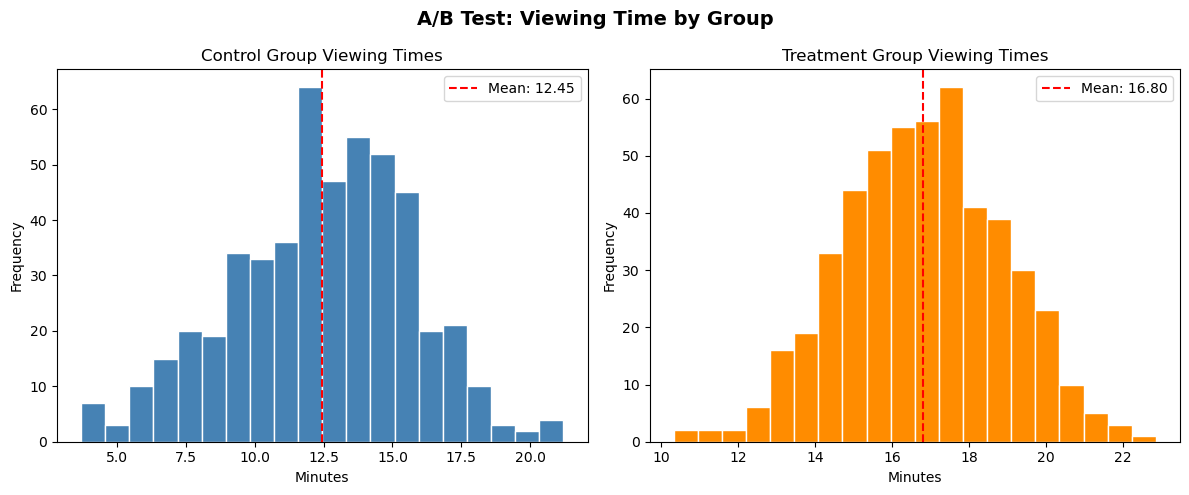

In [10]:
# TODO: create a data visualization to view differences in dispersion and mean
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.hist(control, bins=20, color='steelblue', edgecolor='white')
ax1.axvline(control_mean, color='red', linestyle='--', linewidth=1.5, label=f'Mean: {control_mean:.2f}')
ax1.set_title('Control Group Viewing Times')
ax1.set_xlabel('Minutes')
ax1.set_ylabel('Frequency')
ax1.legend()

ax2.hist(treatment, bins=20, color='darkorange', edgecolor='white')
ax2.axvline(treatment_mean, color='red', linestyle='--', linewidth=1.5, label=f'Mean: {treatment_mean:.2f}')
ax2.set_title('Treatment Group Viewing Times')
ax2.set_xlabel('Minutes')
ax2.set_ylabel('Frequency')
ax2.legend()

fig.suptitle('A/B Test: Viewing Time by Group', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 4. Your Data Findings

What did you discover about your two datasets? Which group has the highest viewing time? What would you want to investigate next?

The treatment group had a  higher average viewing time than the control group . The treatment mean was 16.80 minutes compared to a control mean of 12.45 minutes, a difference of roughly 4.35 minutes, or about 35% longer engagement.

The  control group had a standard deviation of 3.26 minutes, while the treatment group's standard deviation was 2.09 minutes. This means the treatment group watched longer on average, and their viewing times were also more consistent (clustered closely around the mean). The control group had much more spread, with 20 outliers ranging from as low as 3.69 minutes to as high as 20.95 minutes. This suggests that some employees  quickly disengaged while others stayed much longer.

The treatment group also had 20 outliers, but they fell between 10.33 and 22.85 minutes and a more narrow band overall, which aligns with the lower standard deviation.

 The redesigned slides appear to have a more positive effect on engagement. Employees who viewed the lower word-count slides watched longer and more consistently. The high dispersion in the control group may indicate that text-heavy slides caused some viewers to disengage early, while the treatment group remained focused.

 Next, I would like to investigate whether viewing shorter slides has a correlation with higher test scores or knowledge retention, and I would run another test to confirm the difference between groups.